# Medical Insurance Forecast Using ML
Predicting Medical Insurance using Regression

**age:** age of primary beneficiary

**sex:** insurance contractor gender, female, male

**bmi:** Body mass index, providing an understanding of body, weights that are relatively high or low relative to height,
objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9

**children:** Number of children covered by health insurance / Number of dependents

**smoker:** Smoking

**region:** the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.

**charges:** Individual medical costs billed by health insurance

In [1]:
#Fundamental ML Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
medical_df = pd.read_csv('../data/insurance.csv') # ../ For if the file is in another folder

In [4]:
medical_df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
#Number of Rows and Columns

rows = medical_df.shape[0]
columns = medical_df.shape[1]

In [6]:
print('Rows: ', rows,'\nColumns: ', columns)

Rows:  1338 
Columns:  7


## Data Overview

In [7]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## Data Preprocessing (Cleaning)

In [8]:
#Null

print(medical_df.isnull().sum().sum())

0


In [9]:
#Duplicates

print(medical_df.duplicated().sum())

1


In [10]:
medical_df.drop_duplicates(inplace = True)

In [11]:
#Re-check Duplicates

print(medical_df.duplicated().sum())

0


## Exploratory Data Analysis

- Distribution of Sex
- Distribution of Smoker
- Distribution of Children
- Distribution of Region 
- Smokers in Each Region
- Total Medical Inusrance Cost by Region
- Average Medical Insurance Cost by Gender
- Average Medical Insurance Cost by Region

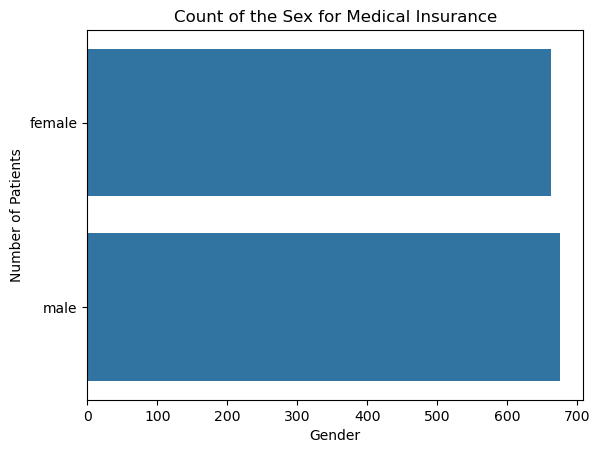

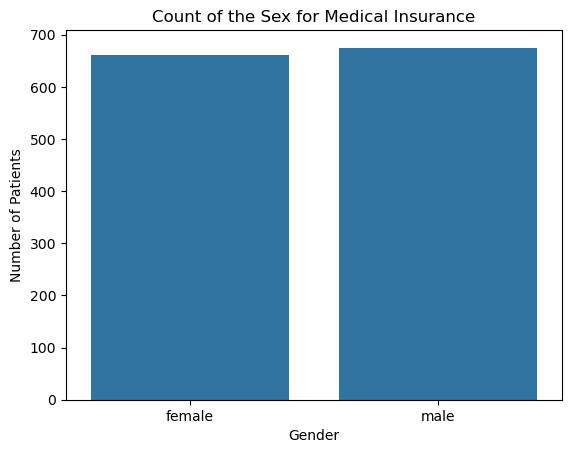

In [12]:
#Distribution of Sex
sns.countplot(y = medical_df['sex'])
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.title('Count of the Sex for Medical Insurance')
plt.show()

sns.countplot(x = medical_df['sex'])
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.title('Count of the Sex for Medical Insurance')
plt.show()

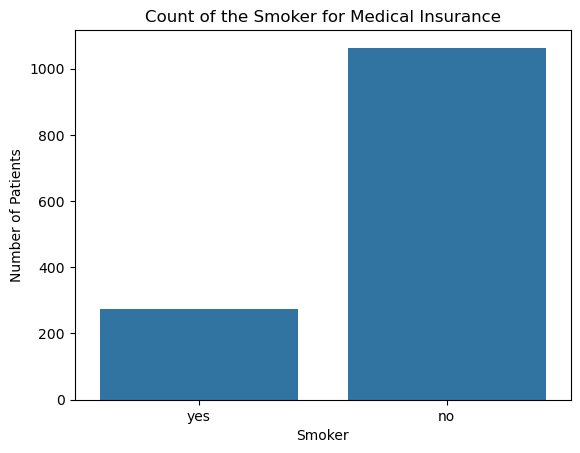

In [13]:
#Distribution of Smoker
sns.countplot(x = medical_df['smoker'])
plt.xlabel('Smoker')
plt.ylabel('Number of Patients')
plt.title('Count of the Smoker for Medical Insurance')
plt.show()

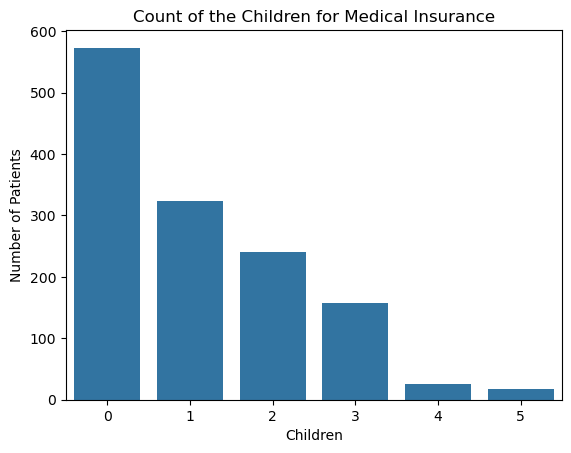

In [14]:
#Distribution of Children
sns.countplot(x = medical_df['children'])
plt.xlabel('Children')
plt.ylabel('Number of Patients')
plt.title('Count of the Children for Medical Insurance')
plt.show()

In [15]:
#Children less than 3
children_three = medical_df[medical_df['children'] <= 3]

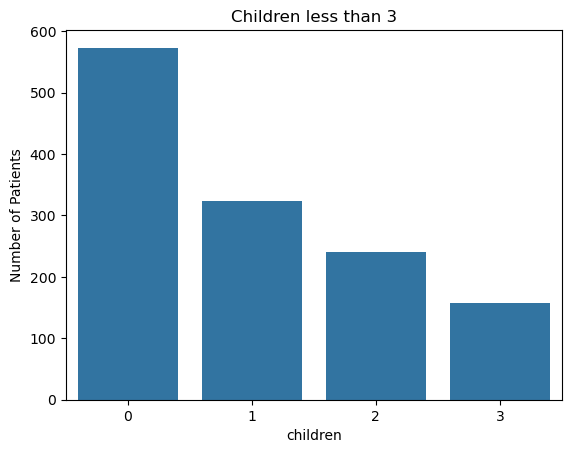

In [16]:
sns.countplot(x = children_three['children'])
plt.xlabel('children')
plt.ylabel('Number of Patients')
plt.title('Children less than 3')
plt.show()

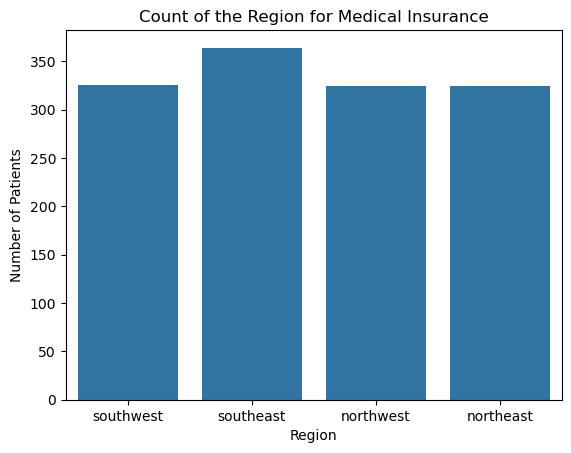

In [17]:
#Distribution of Region
sns.countplot(x = medical_df['region'])
plt.xlabel('Region')
plt.ylabel('Number of Patients')
plt.title('Count of the Region for Medical Insurance')
plt.show()

In [18]:
#Smokers in Each Region
smokers_alone = medical_df[medical_df['smoker']=='yes']

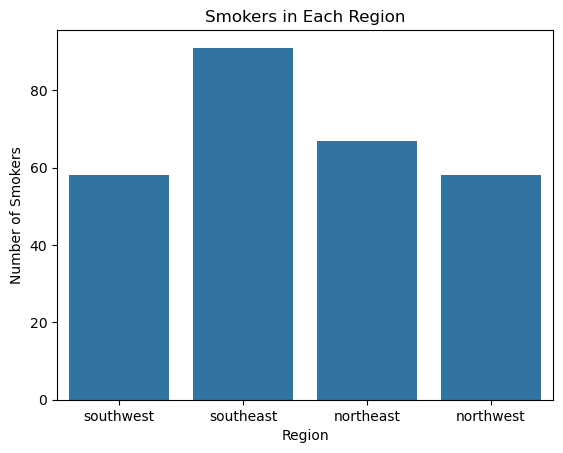

In [19]:
sns.countplot(x = smokers_alone['region'])
plt.xlabel('Region')
plt.ylabel('Number of Smokers')
plt.title('Smokers in Each Region')
plt.show()

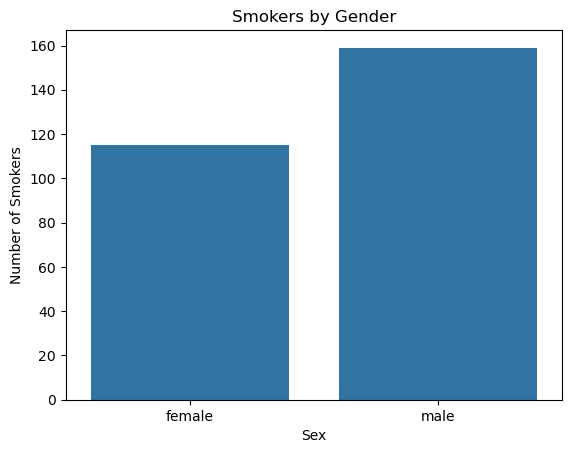

In [20]:
sns.countplot(x = smokers_alone['sex'])
plt.xlabel('Sex')
plt.ylabel('Number of Smokers')
plt.title('Smokers by Gender')
plt.show()

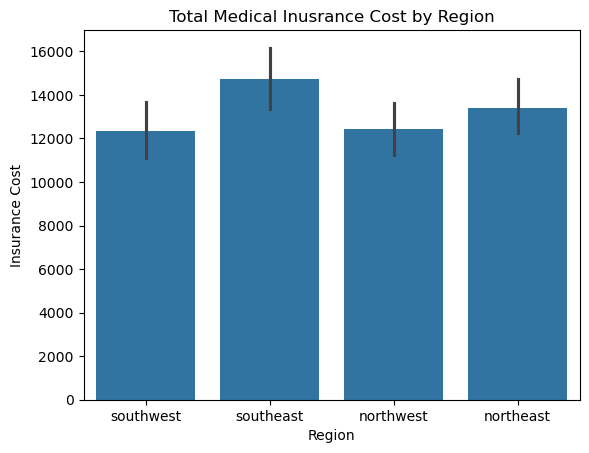

In [21]:
#Total Medical Inusrance Cost by Region

sns.barplot(x = medical_df['region'], y = medical_df['charges'])
plt.xlabel('Region')
plt.ylabel('Insurance Cost')
plt.title('Total Medical Inusrance Cost by Region')
plt.show()

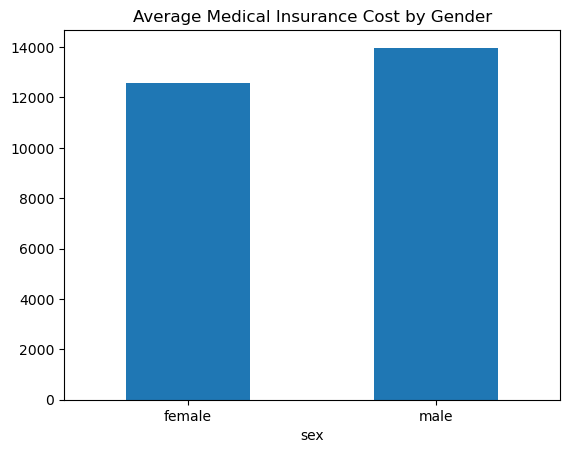

In [22]:
# Average Medical Insurance Cost by Gender

medical_df.groupby('sex')['charges'].mean().plot(kind = 'bar')
plt.title('Average Medical Insurance Cost by Gender')
plt.xticks(rotation = 360)
plt.show()

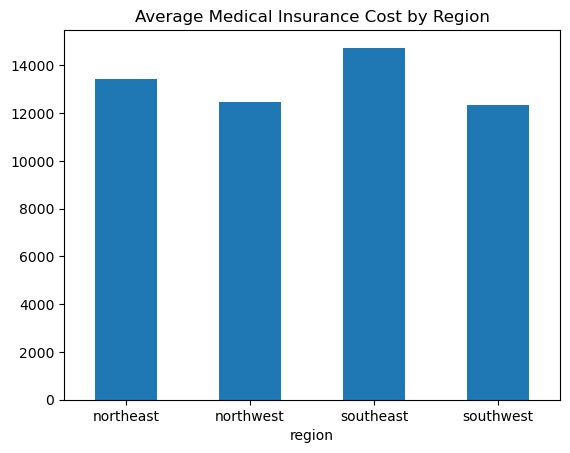

In [23]:
# Average Medical Insurance Cost by Gender

medical_df.groupby('region')['charges'].mean().plot(kind = 'bar')
plt.title('Average Medical Insurance Cost by Region')
plt.xticks(rotation = 360)
plt.show()

## Modeling

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [26]:
x = medical_df.drop('charges', axis = 1)
y = medical_df['charges']

In [27]:
numeric_cols = x.select_dtypes(include = ['number']).columns.tolist()
categorical_cols = x.select_dtypes(include = ['object']).columns.tolist()

In [28]:
numeric_cols

['age', 'bmi', 'children']

In [29]:
categorical_cols

['sex', 'smoker', 'region']

## Pipelines

In [31]:
# Pipiline for Numeric (To scale) and Categorical (To encode)

numeric_pipeline = Pipeline(steps = [('numericPipeline', StandardScaler())])
categorical_pipeline = Pipeline(steps = [('categoricalPipeline', OneHotEncoder(handle_unknown = 'ignore'))]) # The handle to ignore unrelated data

In [32]:
from sklearn.compose import ColumnTransformer

In [37]:
#Preprocessing pipeline
ml_preprocess = ColumnTransformer(

    transformers = [

        ('TransformNumeric', numeric_pipeline, numeric_cols),
        ('TransformCategory', categorical_pipeline, categorical_cols),
        
    ])

        
        

In [41]:
from sklearn.model_selection import train_test_split


In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size= 0.2)

In [44]:
#Import ML Algorithms

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [45]:
lr_model = Pipeline(steps = [('preprocess', ml_preprocess), ('linearModel', LinearRegression())])

In [46]:
dt_model = Pipeline(steps = [('preprocess', ml_preprocess), ('DecisionTree', DecisionTreeRegressor())])

In [47]:
rf_model = Pipeline(steps = [('preprocess', ml_preprocess), ('RandomForest',RandomForestRegressor())])

In [48]:
svm_model = Pipeline(steps = [('preprocess', ml_preprocess), ('SVC',SVR())])

### Training the models

In [50]:
lr_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('linearModel', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
dt_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('DecisionTree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
rf_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('RandomForest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [53]:
svm_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('SVC', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Testing the models

In [55]:
lr_y = lr_model.predict(x_test)
dt_y = dt_model.predict(x_test)
rf_y = rf_model.predict(x_test)
svm_y = svm_model.predict(x_test)

### Performance Evaluation

In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [57]:
log_eval = [mean_absolute_error(y_test, lr_y),  mean_squared_error(y_test, lr_y), root_mean_squared_error(y_test, lr_y), r2_score(y_test, lr_y)]
dt_eval = [mean_absolute_error(y_test, dt_y),  mean_squared_error(y_test, dt_y), root_mean_squared_error(y_test, dt_y), r2_score(y_test, dt_y)]
rf_eval = [mean_absolute_error(y_test, rf_y),  mean_squared_error(y_test, rf_y), root_mean_squared_error(y_test, rf_y), r2_score(y_test, rf_y)]
svm_eval = [mean_absolute_error(y_test, svm_y),  mean_squared_error(y_test, svm_y), root_mean_squared_error(y_test, svm_y), r2_score(y_test, svm_y)]

In [58]:
for i in range(4):
    log_eval[i] = np.round(log_eval[i], 2)
    dt_eval[i] = np.round(dt_eval[i], 2)
    rf_eval[i] = np.round(rf_eval[i], 2)
    svm_eval[i] = np.round(svm_eval[i], 2)

In [59]:
regression_performance = pd.DataFrame({
'Models': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM'],
'MAE': [log_eval[0], dt_eval[0], rf_eval[0], svm_eval[0]],
'MSE': [log_eval[1], dt_eval[1], rf_eval[1], svm_eval[1]],
'RMSE': [log_eval[2], dt_eval[2], rf_eval[2], svm_eval[2]],
'R2': [log_eval[3], dt_eval[3], rf_eval[3], svm_eval[3]],
})

In [60]:
regression_performance

,Models,MAE,MSE,RMSE,R2
0,Logistic Regression,4177.05,3.547802e+07,5956.34,0.81
1,Decision Tree,2669.89,3.654130e+07,6044.94,0.80
2,Random Forest,2590.98,2.157565e+07,4644.96,0.88
3,SVM,9260.28,2.080903e+08,14425.34,-0.13


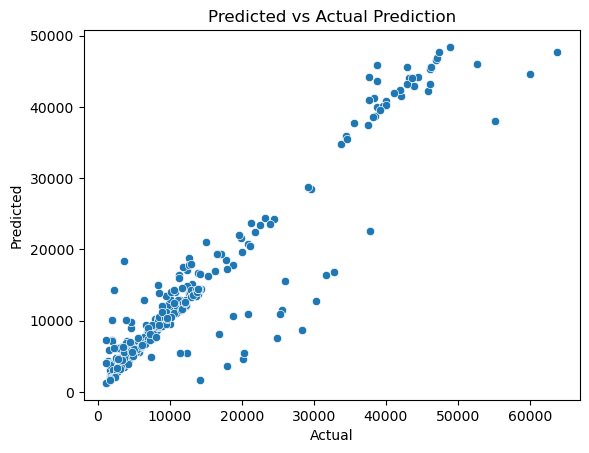

In [61]:
# Using Random Forest

sns.scatterplot(x=y_test, y=rf_y)
plt.title('Predicted vs Actual Prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [63]:
sampleData = pd.DataFrame({

    'age' : [35],
    'sex' :	['male'],
    'bmi' : [34.2],	
    'children' : [5],	
    'smoker' :	['yes'],
    'region' : ['southwest'],
        
})

In [67]:
#Predict Insurance Charge

insurance_prediction = rf_model.predict(sampleData)[0]

In [68]:
print(insurance_prediction)

40264.122724999965


In [70]:
import joblib

In [73]:
 joblib.dump(rf_model, '../models/model.pkl')

['../models/model.pkl']

In [74]:
ml_model = joblib.load('../models/model.pkl')